# AutoML LOOCV (Paired) — FC + PCA 압축

- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + FC를 **PCA로 압축한 주성분 N개**
- **제거 변수**: age, sex, **mean_fd** / **타겟**: vas_t1

PCA는 각 fold의 **train 데이터로만** 학습하고 test에는 변환만 적용한다(누수 방지).
PCA는 y를 보지 않는 비지도 기법이라 train만 쓰는 규칙만 지키면 된다.

`N_PCA` 값을 바꿔가며 몇 개가 적당한지 확인한다. morph에서는 3성분이 최적이었다.

## morph 노트북과 달라진 점

| | morph | 이 노트북 |
|---|---|---|
| 데이터 | `structural_full_68_68_16_edited.csv` | `fc_strength_68_16.csv` 또는 `fc_full_84x84_edited.csv` |
| n | 45 | **44** (sub-001은 ses-t0 fmriprep 크래시로 MNI preproc BOLD 없음) |
| 교란변수 | age, sex, **eTIV** | age, sex, **mean_fd** |
| 뇌 피처 | morph 152개 | strength 84개 **또는** edge 3486개 |

eTIV(두개내용적)는 피질 두께/부피 보정용이라 상관 기반 FC와 무관하다.
반면 head motion(mean framewise displacement)은 FC를 체계적으로 왜곡하는 대표적 교란변수다.

**n이 다르므로 morph 결과(n=45)와 직접 비교하려면 morph를 rid=1 제외 후 재실행해야 한다.**

## 아틀라스 표기 주의

FC 파일명이 `FreeSurferDKT_`이지만 실제 라벨 세트는 **DK**다
(`bankssts`, `frontalpole`, `temporalpole` 포함 — DKT에서 제거된 라벨. DKT는 62개, DK는 68개).
논문에는 `Desikan-Killiany atlas (68 cortical) + FreeSurfer aseg (16 subcortical)`로 표기할 것.

## FC_LEVEL 스위치

맨 위 설정 셀의 `FC_LEVEL`로 strength(84) / edge(3486)를 고른다.
같은 파이프라인을 두 해상도에 그대로 적용하기 위한 것이다.


In [1]:
import os

# [필수] joblib 병렬 워커가 임시 폴더 경로를 ascii로 인코딩하는데,
# 기본 temp 경로(C:\Users\임성은\...)에 한글이 있어 UnicodeEncodeError로 죽는다.
# ascii 경로를 지정해야 n_jobs=-1이 동작한다.
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 0. 설정 — strength(84) / edge(3486) 선택
# ==========================================================
FC_LEVEL = 'strength'      # 'strength' 또는 'edge'

FC_FILES = {
    'strength': 'fc_strength_68_16.csv',    # ROI별 node strength 84개
    'edge':     'fc_full_84x84_edited.csv', # 상삼각 edge 3486개
}
FC_CSV = FC_FILES[FC_LEVEL]
print('사용 파일:', FC_CSV)


사용 파일: fc_strength_68_16.csv


In [3]:
# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
df = pd.read_csv(FC_CSV, skipinitialspace=True)
df.columns = df.columns.str.strip()

# 앞 7개는 메타(rid, treatment_group, vas_t0, vas_t1, age, sex, mean_fd),
# 8번째 컬럼부터 끝까지가 뇌 피처
X_brain = df.iloc[:, 7:].values
brain_features = df.columns[7:].tolist()

nuisance_covariates = ['age', 'sex', 'mean_fd']    # morph의 eTIV 자리를 mean_fd가 대체
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

print(f'n = {len(df)},  brain features = {X_brain.shape[1]}  (p/n = {X_brain.shape[1]/len(df):.1f})')


n = 44,  brain features = 84  (p/n = 1.9)


In [4]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=44면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

# [추가] PCA로 뽑을 주성분 개수. 최대값은 min(train 인원-1, 피처 수) = 43
N_PCA = 3

In [5]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []
evr_log = []   # [추가] fold별 PCA 설명 분산 비율

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_brain)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_b_train, X_b_test = X_brain[train_idx], X_brain[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_b_train)
    X_b_train_clean = X_b_train - nuisance_regressor.predict(X_n_train)
    X_b_test_clean = X_b_test - nuisance_regressor.predict(X_n_test)

    # --- [추가] PCA: train으로만 학습, test는 변환만 ---
    sc_m = StandardScaler().fit(X_b_train_clean)      # PCA 전에 표준화 필수
    X_b_tr_s = sc_m.transform(X_b_train_clean)
    X_b_te_s = sc_m.transform(X_b_test_clean)

    pca = PCA(n_components=N_PCA, random_state=42).fit(X_b_tr_s)
    X_b_tr_p = pca.transform(X_b_tr_s)
    X_b_te_p = pca.transform(X_b_te_s)
    evr_log.append(pca.explained_variance_ratio_.sum())

    # --- Features Stack (FC 피처 -> 주성분 N_PCA개) ---
    X_train_full = np.hstack([X_b_tr_p, X_c_train])
    X_test_full = np.hstack([X_b_te_p, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3,
                                    scoring='neg_mean_squared_error', n_jobs=-1)
            inner_cv.fit(X_tr, y_train)
            pred = inner_cv.best_estimator_.predict(X_te)
            predictions[(dt, name)].append(pred[0])
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

print("\n\nLOOCV Completed.")
print(f"PCA {N_PCA}개 주성분이 설명한 분산: 평균 {np.mean(evr_log):.1%} (fold별 {np.min(evr_log):.1%} ~ {np.max(evr_log):.1%})")

Starting LOOCV: 6 models x 2 datasets...

Processing fold 44/44...

LOOCV Completed.
PCA 3개 주성분이 설명한 분산: 평균 76.5% (fold별 74.5% ~ 77.6%)


In [6]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함 (좋은 것만 골라 읽게 되므로)

n_pos = int((pivot['dRMSE'] > 0).sum())
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.309
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.081514,1.996230,-0.085284
LinearRegression,2.012871,1.997338,-0.015533
RandomForest,2.290354,2.200693,-0.089661
SVR_Linear,1.953307,2.040615,0.087308
SVR_RBF,2.118176,2.208213,0.090037
XGBoost,2.311303,2.235297,-0.076007



부호 일관성: 6개 중 2개가 +
  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.
  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.081514,0.149324,0.394429,0.008064
1,Clinical_ONLY,ElasticNet,1.996230,0.217604,0.477844,0.001037
6,Brain_Plus_Clinical,LinearRegression,2.012871,0.204505,0.474105,0.001150
0,Clinical_ONLY,LinearRegression,1.997338,0.216736,0.478364,0.001022
10,Brain_Plus_Clinical,RandomForest,2.290354,-0.029937,0.251623,0.099423
4,Clinical_ONLY,RandomForest,2.200693,0.049123,0.327847,0.029816
8,Brain_Plus_Clinical,SVR_Linear,1.953307,0.250889,0.517666,0.000320
2,Clinical_ONLY,SVR_Linear,2.040615,0.182425,0.449354,0.002214
9,Brain_Plus_Clinical,SVR_RBF,2.118176,0.119094,0.355390,0.017914
3,Clinical_ONLY,SVR_RBF,2.208213,0.042613,0.347018,0.021009


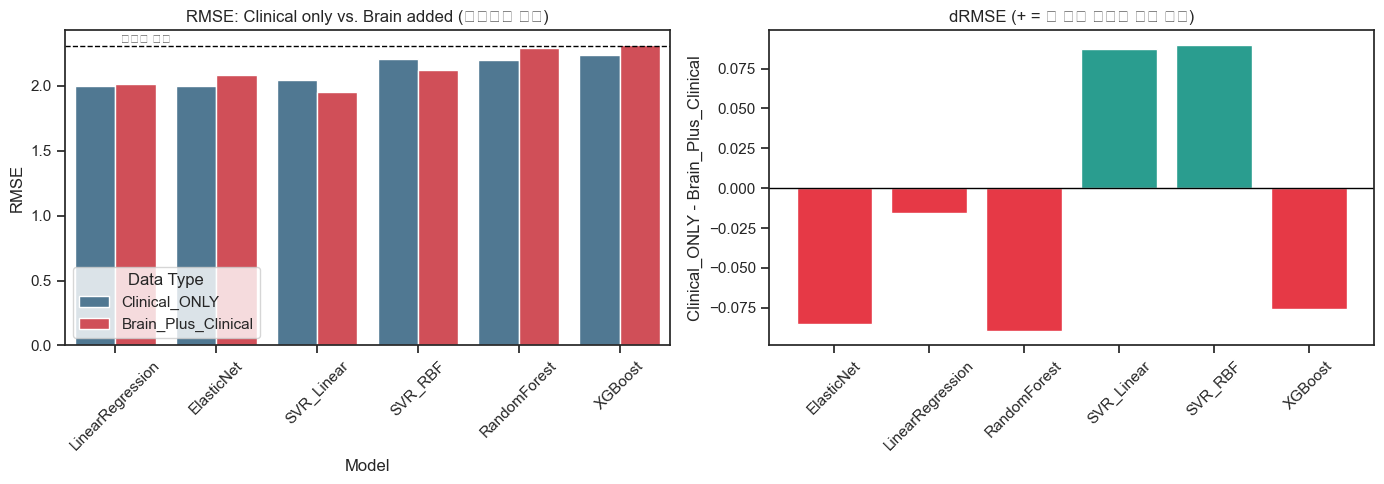

In [7]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[SVR_Linear / Clinical_ONLY] 고유 조합 12개, 최빈 43%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 7개, 최빈 84%
[RandomForest / Clinical_ONLY] 고유 조합 5개, 최빈 61%
[XGBoost / Clinical_ONLY] 고유 조합 4개, 최빈 86%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 6개, 최빈 36%   <-- 불안정
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 12개, 최빈 23%   <-- 불안정
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 15개, 최빈 30%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 7개, 최빈 84%
[XGBoost / Brain_Plus_Clinical] 고유 조합 9개, 최빈 36%   <-- 불안정


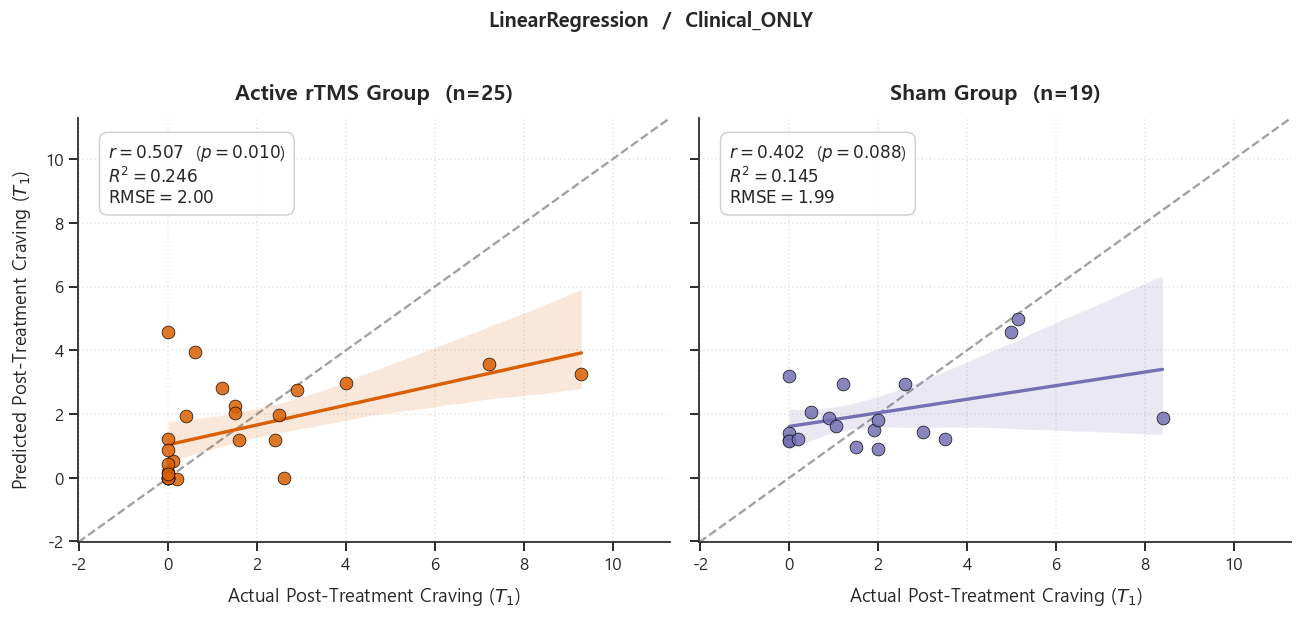

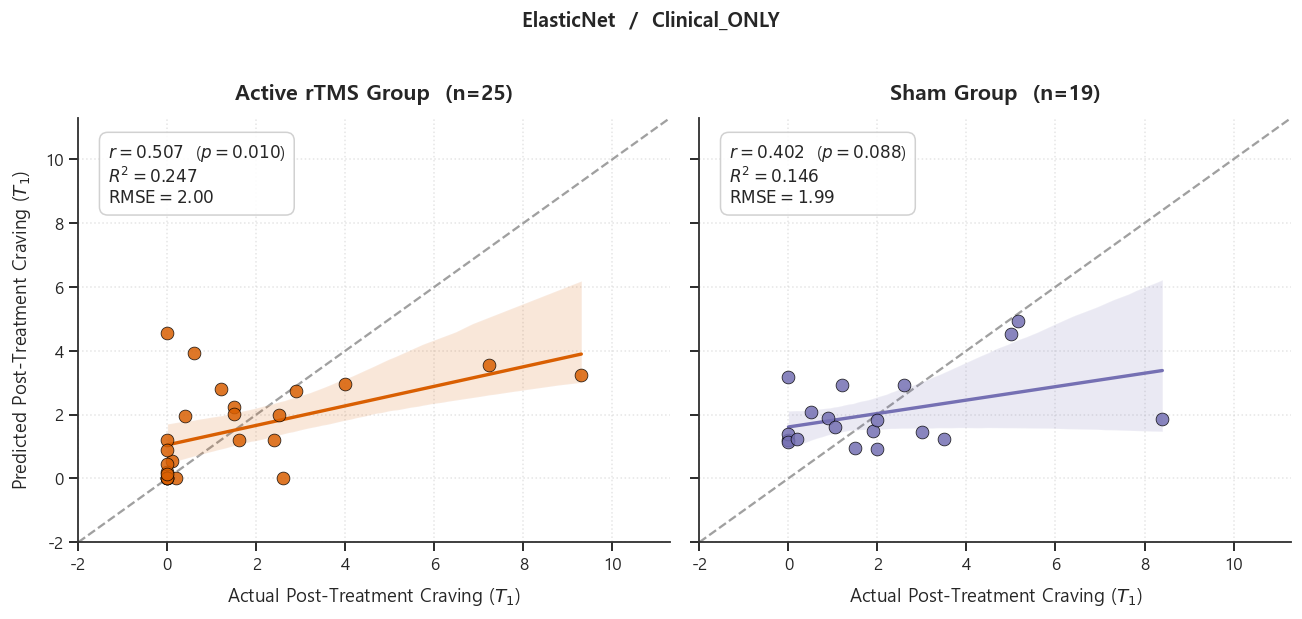

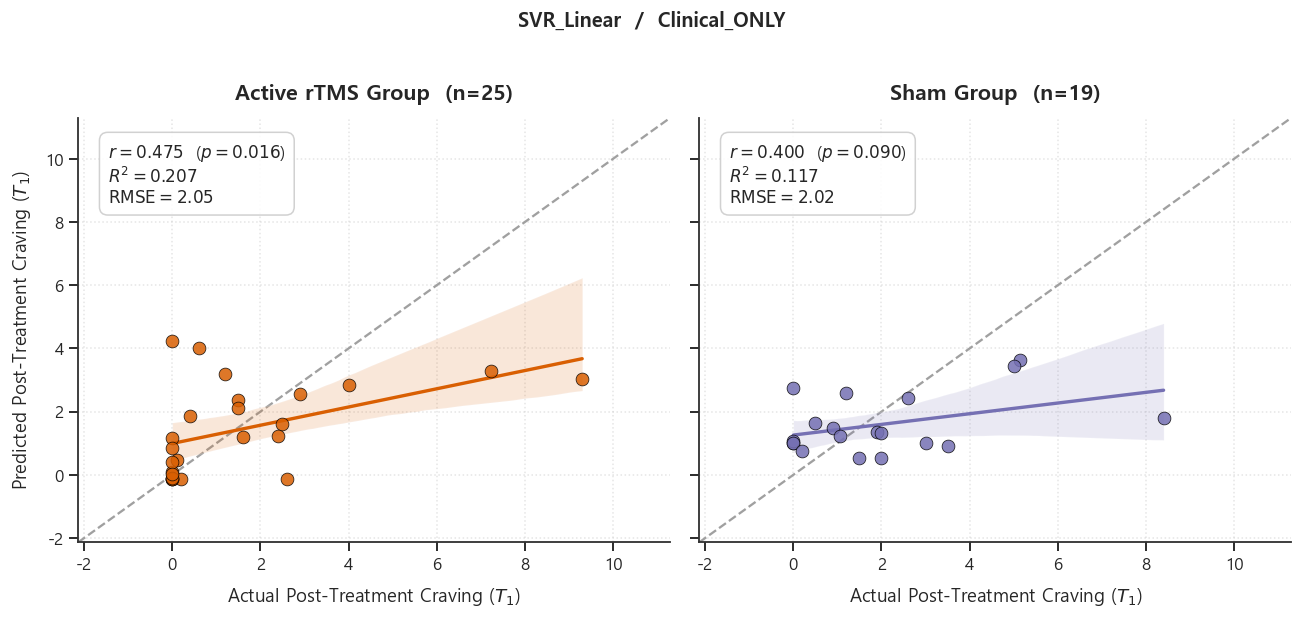

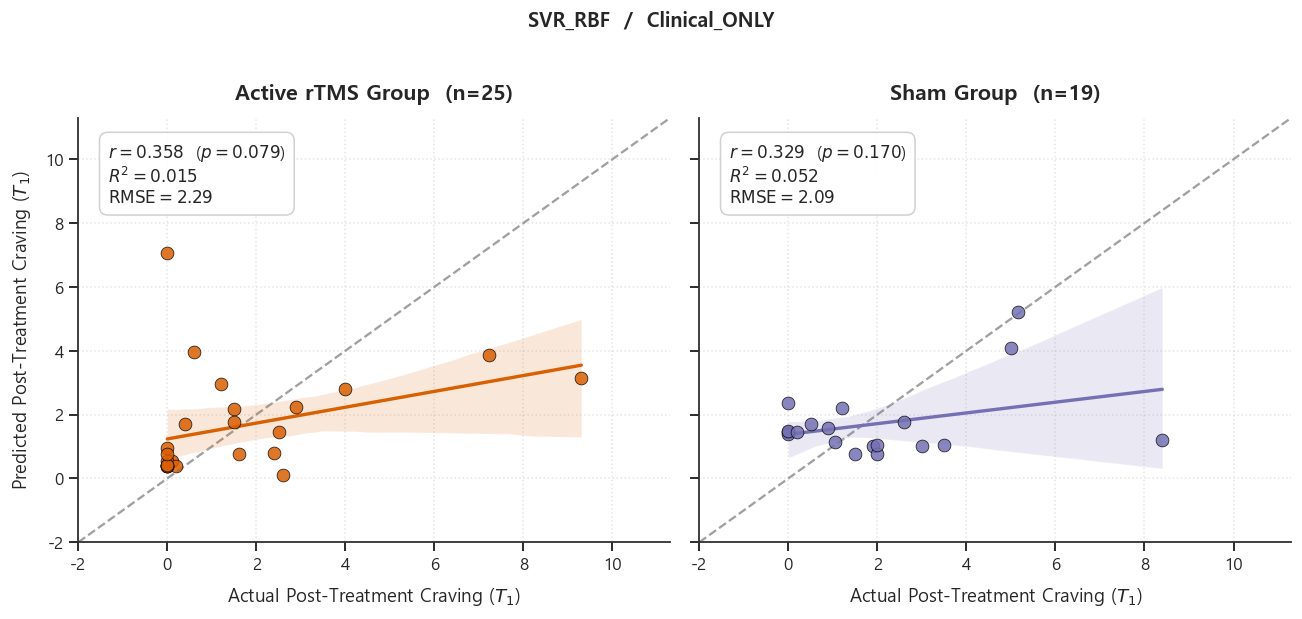

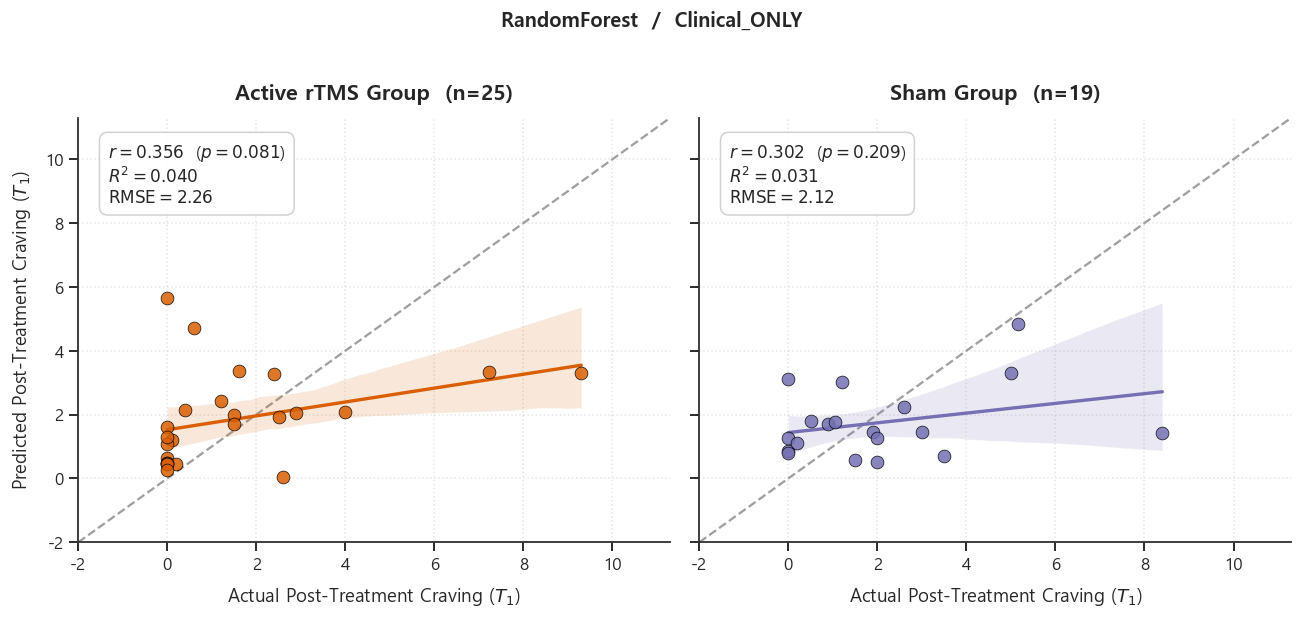

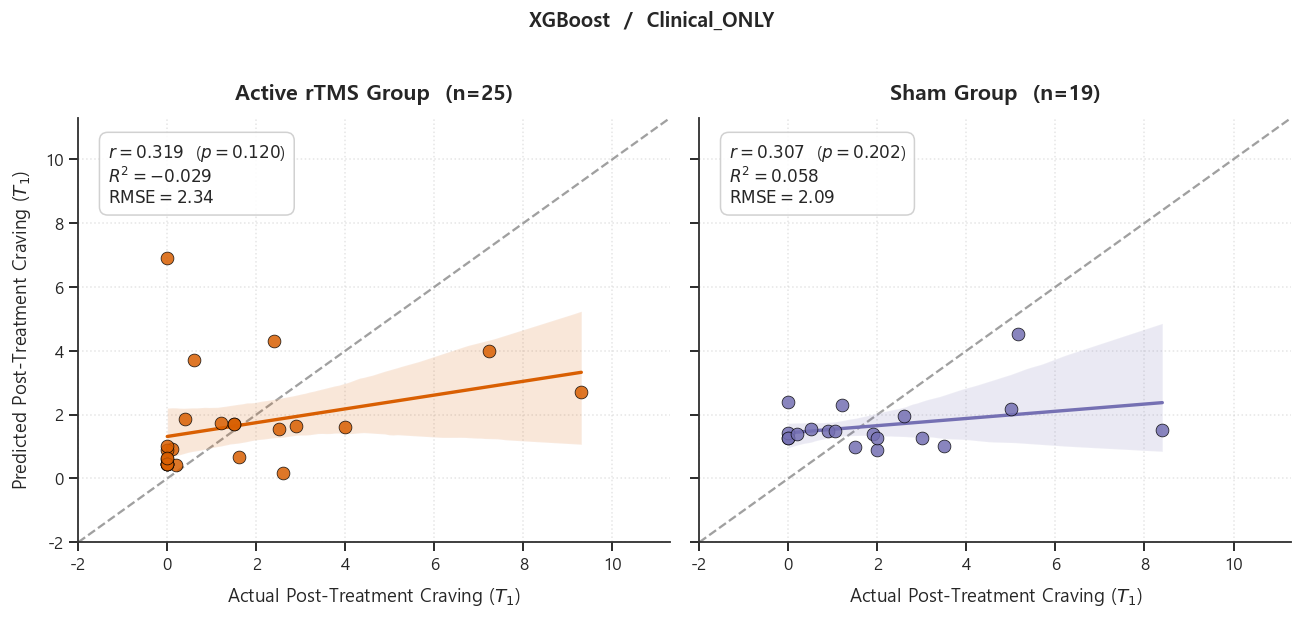

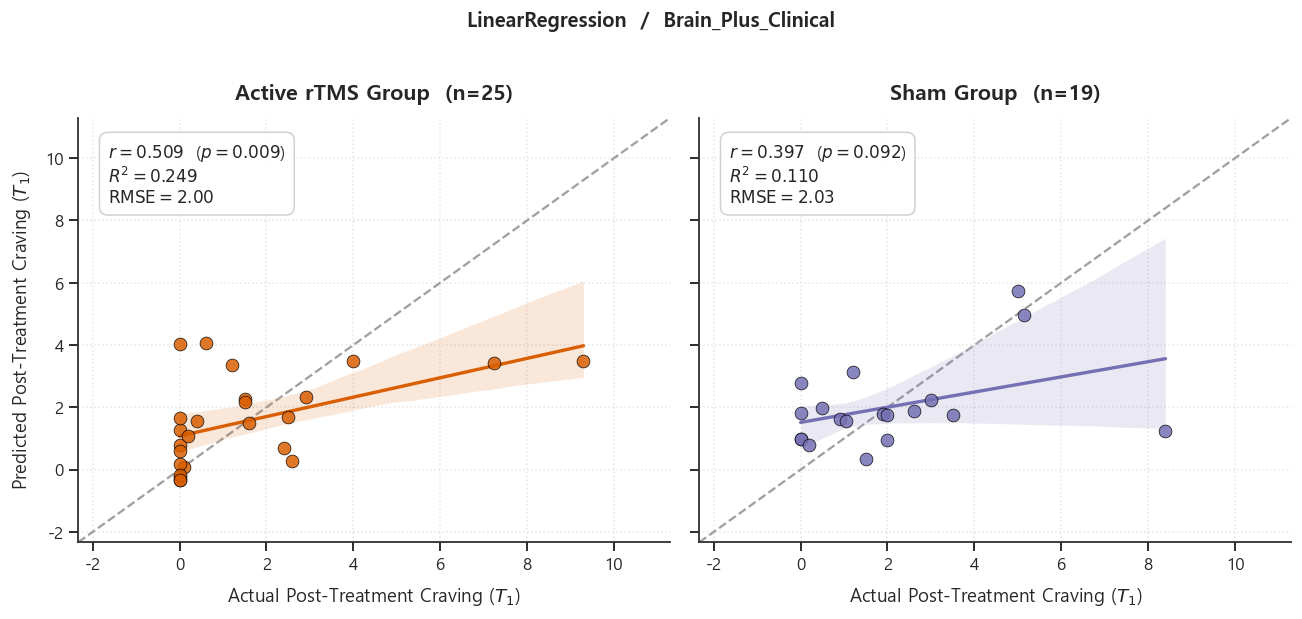

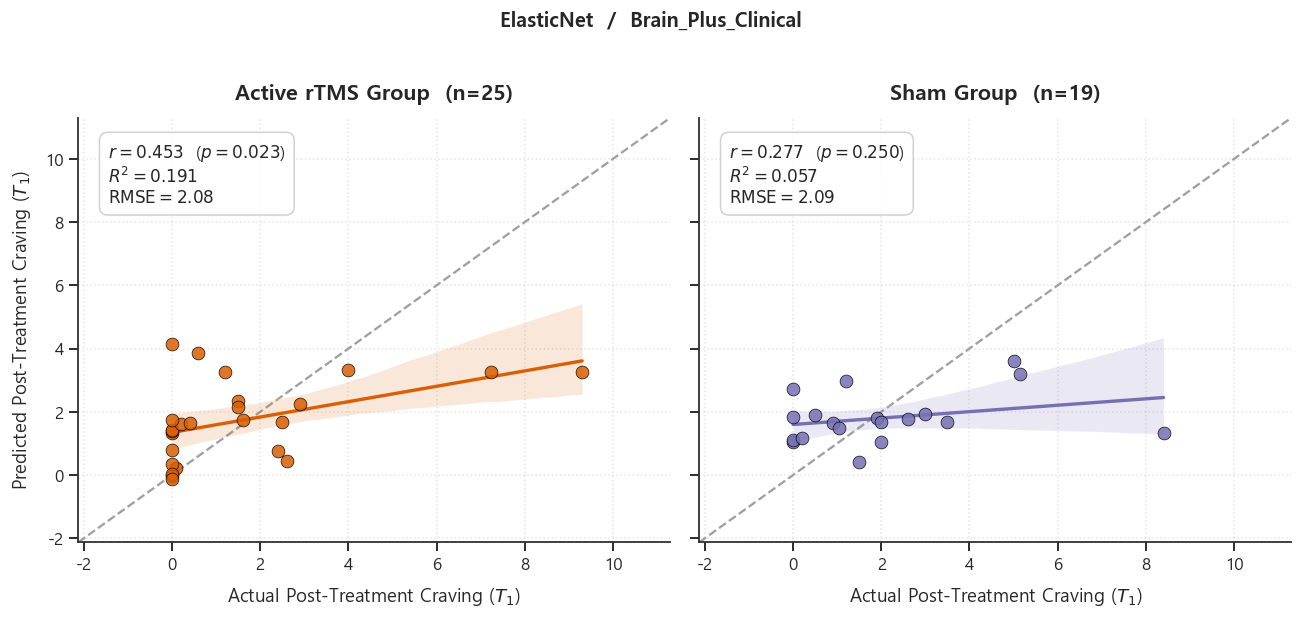

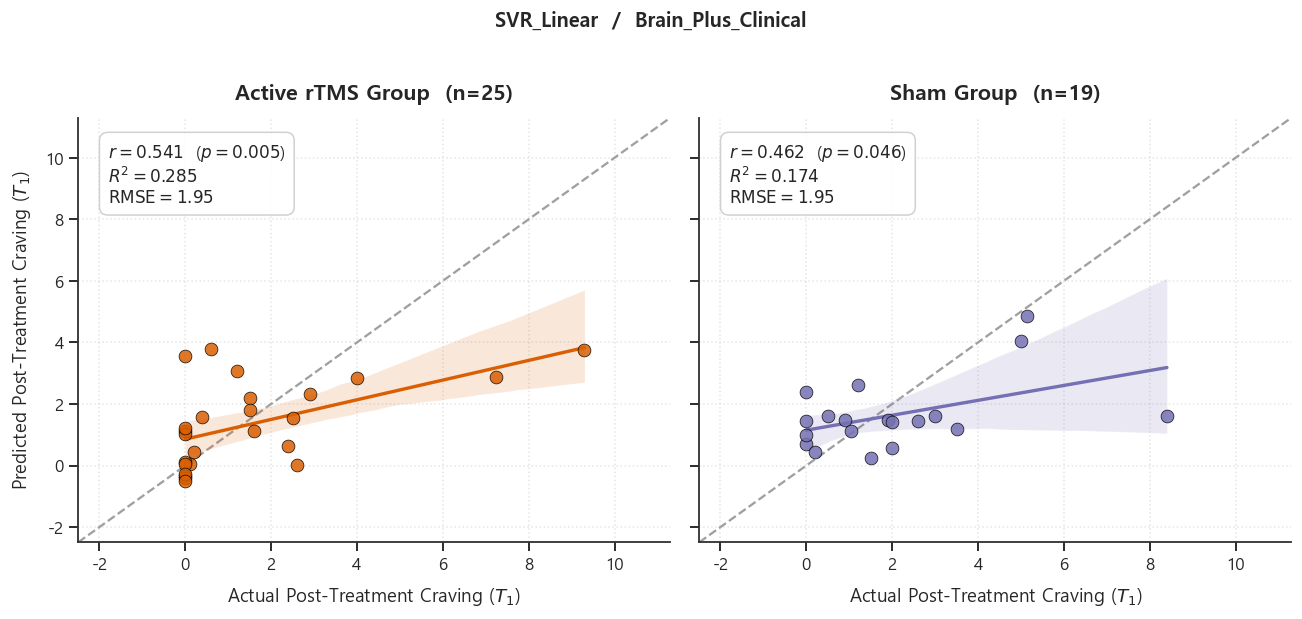

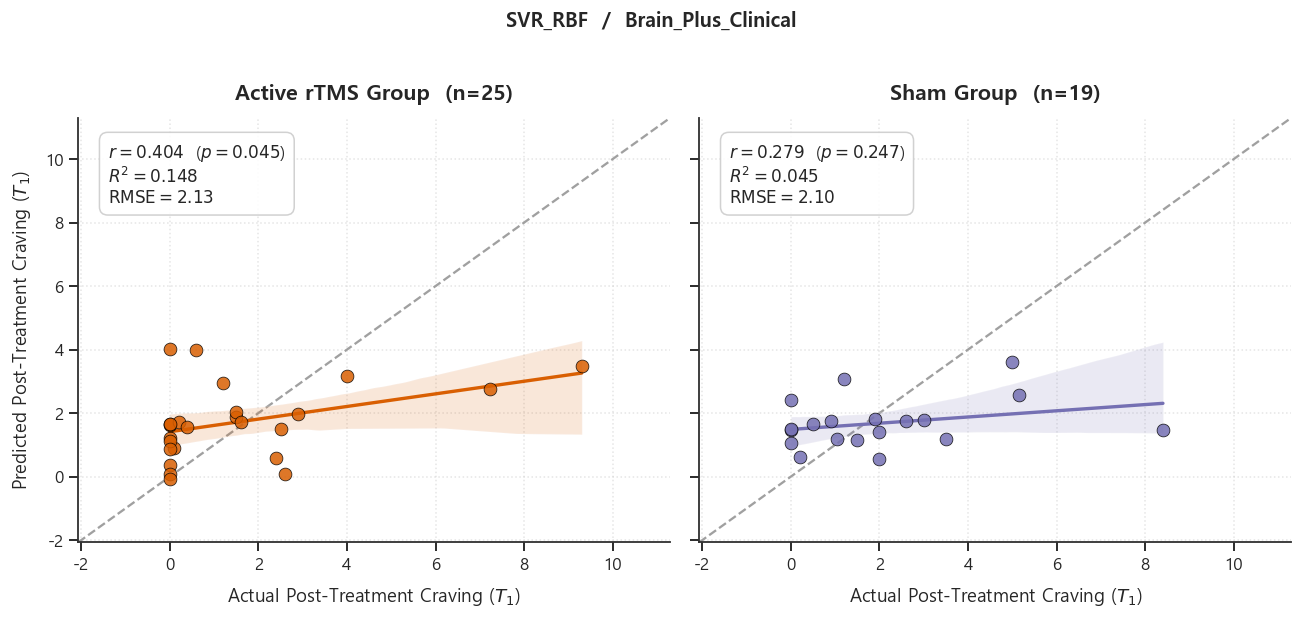

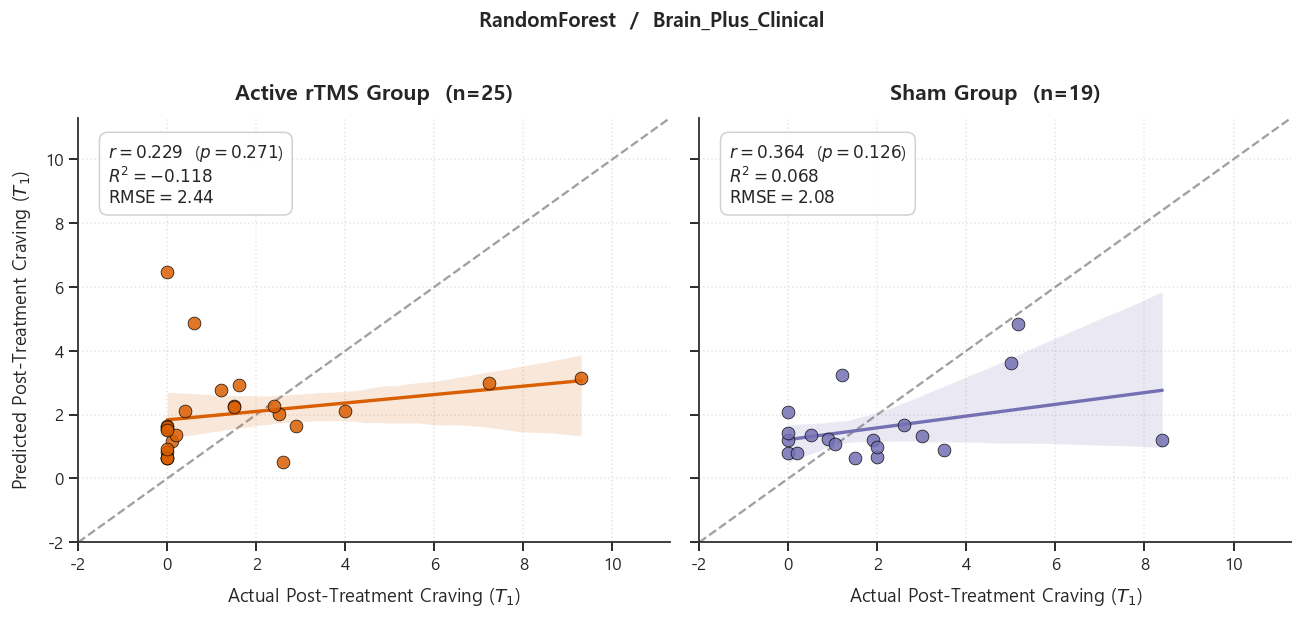

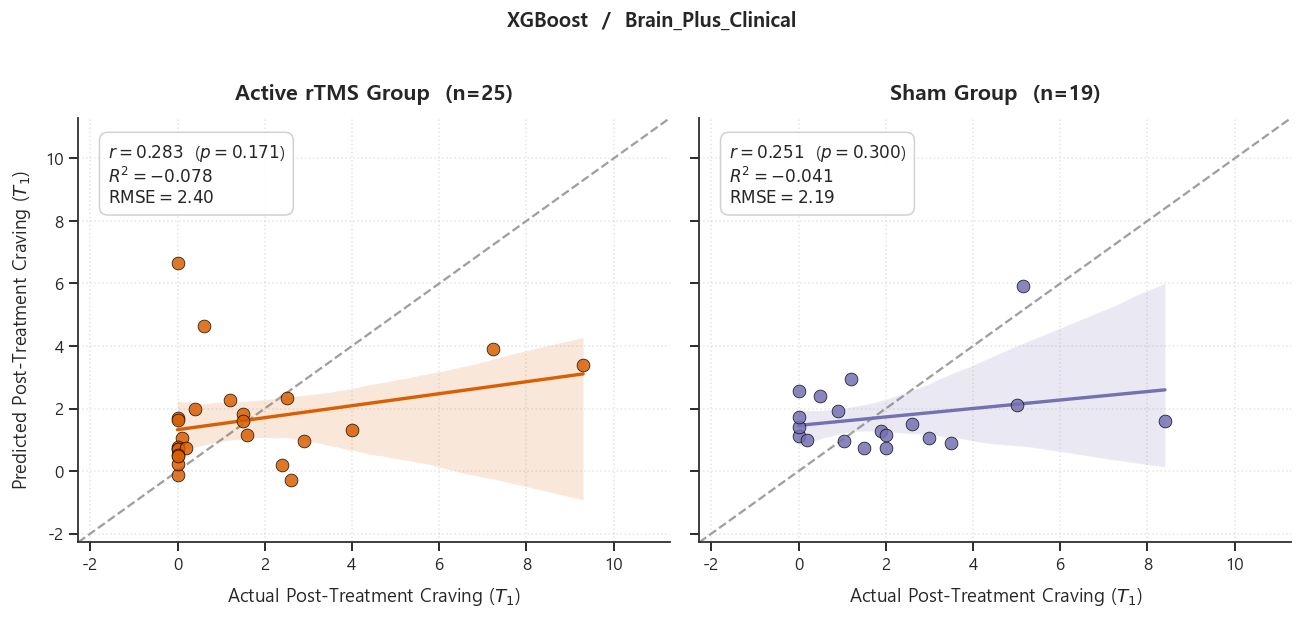

In [9]:
# ==========================================================
# 9. Active vs Sham — 12세트 전부
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'   # Helvetica는 Windows에 없음
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving'])**2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)

        sns.scatterplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            color=color, s=70, alpha=0.85, edgecolor='black',
            linewidth=0.5, ax=ax, zorder=3
        )

        sns.regplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
        )

        ax.set_title(f'{grp} Group  (n={len(sub_df)})',
                     fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(
            0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='#CCCCCC')
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()